# ***Regiones admisibles para los procesos MA(1) y MA(2)***


## **Considere un proceso MA(1):**

$$
(1 - \theta B) q_t = W_t \quad ; \quad q_t \sim WN(0, \sigma^2)
$$

**Recuerde:**  
Este proceso es estacionario, pero **no siempre es invertible**.


**Condición de invertibilidad:**

$$
|\theta| < 1
$$

---

### **A partir de esta condición identificamos dos regiones admisibles**

---



**Región Admisible #1:**

$$
0 < \theta < 1
$$




In [1]:
import plotly.io as pio
pio.renderers.default = "png"
from pizarras.plotly_pages import PlotlyPagesPublisher
publisher = PlotlyPagesPublisher(
    github_username="nuriaarroyo",
    github_repo="ecoII",
    pages_root="docs",
)

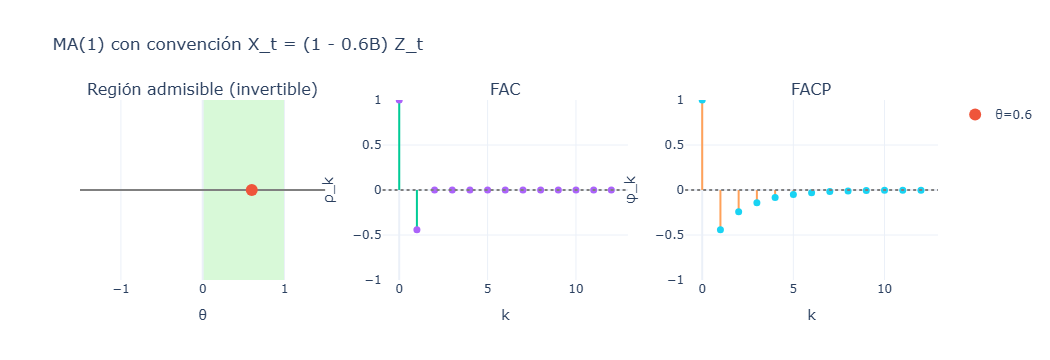

https://nuriaarroyo.github.io/ecoII/interactive/MA_1_con_convenci%C3%B3n_X_t_1_-_0_6B_Z_t.html


In [2]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.default = "png"

# --- util: stem (lineas verticales) ---
def stem_trace(x, y, name):
    xs, ys = [], []
    for xi, yi in zip(x, y):
        xs += [xi, xi, None]
        ys += [0, yi, None]
    lines = go.Scatter(x=xs, y=ys, mode="lines", line=dict(width=2), name=name, showlegend=False)
    dots  = go.Scatter(x=x,  y=y,  mode="markers", marker=dict(size=7), name=f"{name} (•)", showlegend=False)
    return lines, dots

# --- FAC teórica MA(1) con convención X_t = (1 - θ B) Z_t ---
# nota: en esta convención ρ1 = -θ / (1 + θ^2), y ρk = 0 para k >= 2
def acf_ma1(theta, m):
    rho = np.zeros(m+1, dtype=float)
    rho[0] = 1.0
    rho[1] = -theta / (1.0 + theta**2)
    lags = np.arange(m+1)
    return lags, rho

# --- FACP a partir de FAC (Levinson-Durbin "lite") ---
# pacf[0]=1; pacf[k] = φ_kk del AR(k) que ajusta esa FAC
def pacf_from_acf(rho):
    m = len(rho) - 1
    pacf = np.zeros(m+1, dtype=float)
    pacf[0] = 1.0
    if m >= 1:
        # matrices phi[k][j] (guardamos solo la fila previa para ahorrar)
        phi_prev = np.zeros(m+1, dtype=float)
        pacf[1] = rho[1]
        phi_prev[1] = rho[1]
        den_prev = 1.0  # 1 - sum_{j=1}^{k-1} phi_{k-1,j} * rho[j], arranca en 1

        for k in range(2, m+1):
            # num = rho[k] - sum_{j=1}^{k-1} phi_{k-1,j} * rho[k-j]
            num = rho[k] - np.sum(phi_prev[1:k] * rho[1:k][::-1])
            # den = 1 - sum_{j=1}^{k-1} phi_{k-1,j} * rho[j]
            den = 1.0 - np.sum(phi_prev[1:k] * rho[1:k])
            phi_kk = 0.0 if np.isclose(den, 0.0) else num / den
            pacf[k] = phi_kk

            # actualiza todos los φ_k,j
            phi_curr = np.zeros(m+1, dtype=float)
            for j in range(1, k):
                phi_curr[j] = phi_prev[j] - phi_kk * phi_prev[k-j]
            phi_curr[k] = phi_kk

            phi_prev = phi_curr
            den_prev = den
    return pacf

def panel_ma1_region_fac_pacf(theta=0.4, m=12, xlim=1.5):
    fig = make_subplots(
        rows=1, cols=3,
        subplot_titles=("Región admisible (invertible)", "FAC", "FACP"),
        column_widths=[0.33, 0.33, 0.34]
    )

    # --- 1) Región admisible en la recta real (−1 < θ < 1) ---
    fig.add_shape(
        type="rect",
        x0=0, x1=1, y0=0, y1=1,
        xref="x1", yref="paper",
        fillcolor="lightgreen", opacity=0.35, line_width=0, layer="below"
    )
    # eje base
    fig.add_trace(go.Scatter(x=[-xlim, xlim], y=[0,0], mode="lines",
                             line=dict(color="gray", width=2), showlegend=False),
                  row=1, col=1)
    # marca del theta elegido
    fig.add_trace(go.Scatter(x=[theta], y=[0], mode="markers",
                             marker=dict(size=12), name=f"θ={theta}"),
                  row=1, col=1)
    fig.update_xaxes(range=[-xlim, xlim], title_text="θ", row=1, col=1)
    fig.update_yaxes(visible=False, row=1, col=1)

    # --- 2) FAC ---
    lags, rho = acf_ma1(theta, m)
    lines, dots = stem_trace(lags, rho, "ρ_k")
    fig.add_trace(lines, row=1, col=2); fig.add_trace(dots, row=1, col=2)
    fig.add_hline(y=0, line_dash="dot", line_color="gray", row=1, col=2)
    fig.update_yaxes(range=[-1, 1], title_text="ρ_k", row=1, col=2)
    fig.update_xaxes(title_text="k", row=1, col=2)

    # --- 3) FACP (a partir de la FAC) ---
    pacf = pacf_from_acf(rho)
    lags_p = np.arange(len(pacf))
    lines, dots = stem_trace(lags_p, pacf, "φ_k (PACF)")
    fig.add_trace(lines, row=1, col=3); fig.add_trace(dots, row=1, col=3)
    fig.add_hline(y=0, line_dash="dot", line_color="gray", row=1, col=3)
    fig.update_yaxes(range=[-1, 1], title_text="φ_k", row=1, col=3)
    fig.update_xaxes(title_text="k", row=1, col=3)

    fig.update_layout(template="plotly_white", width=1050, height=360,
                      title=f"MA(1) con convención X_t = (1 - {theta}B) Z_t")
    return fig

# ================== USO ==================
# ejemplo: θ = -0.4 (recuerda: convención con signo 'menos' en el polinomio)
fig = panel_ma1_region_fac_pacf(theta=0.6, m=12, xlim=1.5)
fig.show()
out_path, public_url, pdf_url = publisher.save_html(     fig,     site_subfolder="interactive",     print_link=False, ) 
print(pdf_url)


**Modelo**

$$
W_t = (1 - \theta B) a_t
$$

Se muestra la región para $0 < \theta < 1$ en la línea del eje horizontal de la figura.


**FAC teórica**

- Comportamiento de la **Función de Autocorrelación (FAC)**:

$$
\rho_k =
\begin{cases}
\displaystyle\frac{-\theta}{1 + \theta^2} & \text{si } k = 1 \\
0 & \text{si } k \geq 2
\end{cases}
$$

- Solo la **primera autocorrelación** es distinta de cero.
- Además, se cumple:

$$
|\rho_1| \leq 0.5
$$

- En esta región, la autocorrelación es **negativa**: $\rho_1 < 0$



**FACP teórica**

>La **Función de Autocorrelación Parcial (FACP)** decae rápidamente y es casi nula después de los primeros lags.







---

**Región Admisible #2**

Para esta región del modelo MA(1) se cumple:

- $-1 < \theta < 0$



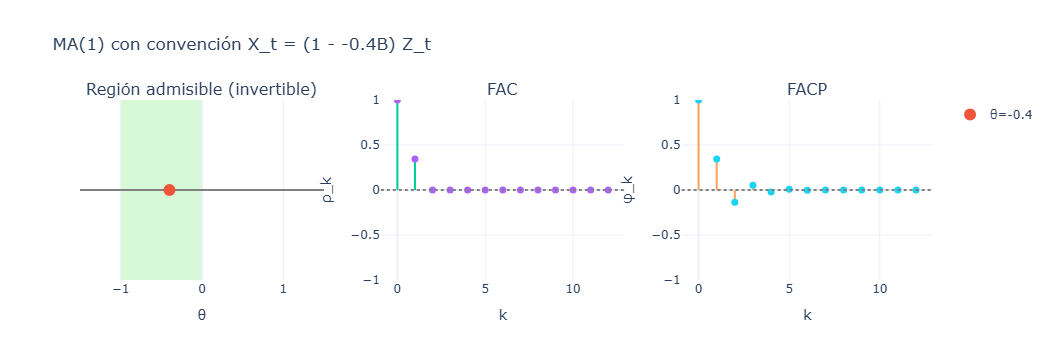

https://nuriaarroyo.github.io/ecoII/interactive/MA_1_con_convenci%C3%B3n_X_t_1_-_-0_4B_Z_t.html


In [3]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- util: stem (lineas verticales) ---
def stem_trace(x, y, name):
    xs, ys = [], []
    for xi, yi in zip(x, y):
        xs += [xi, xi, None]
        ys += [0, yi, None]
    lines = go.Scatter(x=xs, y=ys, mode="lines", line=dict(width=2), name=name, showlegend=False)
    dots  = go.Scatter(x=x,  y=y,  mode="markers", marker=dict(size=7), name=f"{name} (•)", showlegend=False)
    return lines, dots

# --- FAC teórica MA(1) con convención X_t = (1 - θ B) Z_t ---
# nota: en esta convención ρ1 = -θ / (1 + θ^2), y ρk = 0 para k >= 2
def acf_ma1(theta, m):
    rho = np.zeros(m+1, dtype=float)
    rho[0] = 1.0
    rho[1] = -theta / (1.0 + theta**2)
    lags = np.arange(m+1)
    return lags, rho

# --- FACP a partir de FAC (Levinson-Durbin "lite") ---
# pacf[0]=1; pacf[k] = φ_kk del AR(k) que ajusta esa FAC
def pacf_from_acf(rho):
    m = len(rho) - 1
    pacf = np.zeros(m+1, dtype=float)
    pacf[0] = 1.0
    if m >= 1:
        # matrices phi[k][j] (guardamos solo la fila previa para ahorrar)
        phi_prev = np.zeros(m+1, dtype=float)
        pacf[1] = rho[1]
        phi_prev[1] = rho[1]
        den_prev = 1.0  # 1 - sum_{j=1}^{k-1} phi_{k-1,j} * rho[j], arranca en 1

        for k in range(2, m+1):
            # num = rho[k] - sum_{j=1}^{k-1} phi_{k-1,j} * rho[k-j]
            num = rho[k] - np.sum(phi_prev[1:k] * rho[1:k][::-1])
            # den = 1 - sum_{j=1}^{k-1} phi_{k-1,j} * rho[j]
            den = 1.0 - np.sum(phi_prev[1:k] * rho[1:k])
            phi_kk = 0.0 if np.isclose(den, 0.0) else num / den
            pacf[k] = phi_kk

            # actualiza todos los φ_k,j
            phi_curr = np.zeros(m+1, dtype=float)
            for j in range(1, k):
                phi_curr[j] = phi_prev[j] - phi_kk * phi_prev[k-j]
            phi_curr[k] = phi_kk

            phi_prev = phi_curr
            den_prev = den
    return pacf

def panel_ma1_region_fac_pacf(theta=0.4, m=12, xlim=1.5):
    fig = make_subplots(
        rows=1, cols=3,
        subplot_titles=("Región admisible (invertible)", "FAC", "FACP"),
        column_widths=[0.33, 0.33, 0.34]
    )

    # --- 1) Región admisible en la recta real (−1 < θ < 1) ---
    fig.add_shape(
        type="rect",
        x0=-1, x1=0, y0=0, y1=1,
        xref="x1", yref="paper",
        fillcolor="lightgreen", opacity=0.35, line_width=0, layer="below"
    )
    # eje base
    fig.add_trace(go.Scatter(x=[-xlim, xlim], y=[0,0], mode="lines",
                             line=dict(color="gray", width=2), showlegend=False),
                  row=1, col=1)
    # marca del theta elegido
    fig.add_trace(go.Scatter(x=[theta], y=[0], mode="markers",
                             marker=dict(size=12), name=f"θ={theta}"),
                  row=1, col=1)
    fig.update_xaxes(range=[-xlim, xlim], title_text="θ", row=1, col=1)
    fig.update_yaxes(visible=False, row=1, col=1)

    # --- 2) FAC ---
    lags, rho = acf_ma1(theta, m)
    lines, dots = stem_trace(lags, rho, "ρ_k")
    fig.add_trace(lines, row=1, col=2); fig.add_trace(dots, row=1, col=2)
    fig.add_hline(y=0, line_dash="dot", line_color="gray", row=1, col=2)
    fig.update_yaxes(range=[-1, 1], title_text="ρ_k", row=1, col=2)
    fig.update_xaxes(title_text="k", row=1, col=2)

    # --- 3) FACP (a partir de la FAC) ---
    pacf = pacf_from_acf(rho)
    lags_p = np.arange(len(pacf))
    lines, dots = stem_trace(lags_p, pacf, "φ_k (PACF)")
    fig.add_trace(lines, row=1, col=3); fig.add_trace(dots, row=1, col=3)
    fig.add_hline(y=0, line_dash="dot", line_color="gray", row=1, col=3)
    fig.update_yaxes(range=[-1, 1], title_text="φ_k", row=1, col=3)
    fig.update_xaxes(title_text="k", row=1, col=3)

    fig.update_layout(template="plotly_white", width=1050, height=360,
                      title=f"MA(1) con convención X_t = (1 - {theta}B) Z_t")
    return fig

# ================== USO ==================
# ejemplo: θ = -0.4 (recuerda: convención con signo 'menos' en el polinomio)
fig = panel_ma1_region_fac_pacf(theta=-0.4, m=12, xlim=1.5)
fig.show()
out_path, public_url, pdf_url = publisher.save_html(     fig,     site_subfolder="interactive",     print_link=False, ) 
print(pdf_url)



**Modelo**

$$
W_t = (1 - \theta B) a_t
$$

Ejemplo específico:

- $\theta = -0.4$

**FAC teórica:**

Se utiliza la fórmula:

$$
\rho_k =
\begin{cases}
\displaystyle\frac{-\theta}{1 + \theta^2} & \text{si } k = 1 \\
0 & \text{si } k \geq 2
\end{cases}
$$

Sustituyendo:

$$
\rho_1 = \frac{-(-0.4)}{1 + (-0.4)^2} = \frac{0.4}{1 + 0.16} = \frac{0.4}{1.16} \approx 0.3448
$$

Entonces:

- $\rho_1 \approx 0.34 > 0$
- $\rho_k = 0$ para $k \geq 2$


---

## **Considere un proceso MA(2):**

$$
(1 - \theta_1 B - \theta_2 B^2) \alpha_t = W_t \quad ; \quad \alpha_t \sim WN(0, \sigma^2)
$$


**Condiciones para probar invertibilidad:**

1. $|\theta_2| < 1$

2. $\theta_2 + \theta_1 < 1$

3. $\theta_2 - \theta_1 < 1$

---

### **De aquí surgen las siguientes regiones admisibles**

---


In [4]:
import numpy as np
import plotly.graph_objects as go

def ma2_region_quad(theta1_point=0.4, theta2_point=0.2):
    x = np.linspace(-2, 2, 600)
    

    # fronteras del triángulo (estacionariedad)
    tri_x = [-2, 2, 0, -2]
    tri_y = [ -1, -1,1,  -1]

    # curvas de referencia
    disc = -0.25 * x**2          # parábola Δ=0
    y0   = np.zeros_like(x)      # φ2 = 0

    fig = go.Figure()

    
    
    # triángulo
    fig.add_trace(go.Scatter(x=tri_x, y=tri_y, mode="lines",
                             line=dict(color="black", width=1), # Borde negro
                             fill="toself", fillcolor="rgba(144, 238, 144, 0.4)", # Verde claro con transparencia
                             name="Región de Estacionariedad"))

    # parábola (discriminante)
    fig.add_trace(go.Scatter(x=x, y=disc, mode="lines",
                             line=dict(color="black", width=2, dash="dot"),
                             name="Δ=0  (θ₂ = −¼ θ₁²)"))




    # marcas en los vértices
    fig.add_trace(go.Scatter(x=[-2, 2, 0], y=[1, 1, -1], mode="markers+text",
                             marker=dict(size=6, color="black"),
                             text=["(-2,1)", "(2,1)", "(0,-1)"],
                             textposition="top center",
                             showlegend=False))

    # tu punto
    fig.add_trace(go.Scatter(x=[theta1_point], y=[theta2_point], mode="markers+text",
                             marker=dict(size=12, color="red", symbol="circle"),
                             text=[f"({theta1_point:.2f}, {theta2_point:.2f})"],
                             textposition="bottom center",
                             name="punto (θ₁, θ₂)"))

    # etiquetas rápidas de sub-regiones (opcional)
    fig.add_annotation(x=-1.0, y=0.3, text="Real\n(θ₁<0)", showarrow=False)
    fig.add_annotation(x= 1.0, y=0.3, text="Real\n(θ₁>0)", showarrow=False)
    fig.add_annotation(x=-1.0, y=-0.6, text="Compleja\n(θ₁<0)", showarrow=False)
    fig.add_annotation(x= 1.0, y=-0.6, text="Compleja\n(θ₁>0)", showarrow=False)

    if theta1_point < 0:
        if (theta1_point**2 + 4*theta2_point)<0:
            region = 3
        else:
            region = 1
    else:
        if (theta1_point**2 + 4*theta2_point)<0:
            region = 4
        else:
            region =2

    fig.update_layout(
        template="simple_white",
        width=700, height=520,
        title=f"MA(2)<br> Triángulo de estacionariedad + parábola del discriminante<br>Punto en Región {region}",
        xaxis=dict(title="θ₁", range=[-2.2, 2.2], zeroline=True),
        yaxis=dict(title="θ₂", range=[-1.3, 1.3], zeroline=False),
        showlegend=False
    )
    return fig



In [5]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ========= util: "stem plot" (líneas verticales + marcadores) =========
def stem_trace(x, y):
    xs, ys = [], []
    for xi, yi in zip(x, y):
        xs += [xi, xi, None]
        ys += [0, yi, None]
    lines = go.Scatter(x=xs, y=ys, mode="lines", line=dict(width=2), showlegend=False)
    dots  = go.Scatter(x=x,  y=y,  mode="markers", marker=dict(size=7), showlegend=False)
    return lines, dots

# ========= pesos MA(q) para X_t = (1 - sum θ_j B^j) Z_t =========
def psi_weights_from_ma(theta):
    """
    Convención 'menos θ' en el polinomio: X_t = (1 - θ1 B - θ2 B^2 - ... - θq B^q) Z_t
    -> ψ0 = 1, ψj = -θj para j=1..q
    """
    theta = np.asarray(theta, dtype=float)
    q = len(theta)
    psi = np.zeros(q+1, dtype=float)
    psi[0] = 1.0
    if q > 0:
        psi[1:] = -theta
    return psi

# ========= ACF teórica a partir de psi-weights =========
def acf_from_psi(psi, m):
    M = len(psi) - 1
    gamma = np.zeros(m+1)
    for k in range(m+1):
        # γ_k = sum_{i=0}^{M-k} ψ_i ψ_{i+k}
        gamma[k] = np.dot(psi[:M-k+1], psi[k:M+1])
    rho = gamma / gamma[0]
    return rho

# ========= PACF (Durbin-Levinson) dada la ACF =========
def pacf_from_acf(rho, m):
    # rho: [ρ0..ρm], PACF_k = φ_{kk}
    pacf = np.zeros(m+1)
    pacf[0] = 1.0
    if m == 0: 
        return pacf

    phi = np.zeros((m+1, m+1))
    pacf[1] = rho[1]
    phi[1,1] = rho[1]
    var = np.zeros(m+1)
    var[0] = 1.0
    var[1] = 1 - phi[1,1]**2

    for k in range(2, m+1):
        num = rho[k] - np.sum(phi[k-1,1:k] * rho[1:k][::-1])
        den = var[k-1]
        phi[k,k] = 0.0 if np.isclose(den, 0.0) else num / den
        for j in range(1, k):
            phi[k,j] = phi[k-1,j] - phi[k,k] * phi[k-1,k-j]
        var[k] = var[k-1] * (1 - phi[k,k]**2)
        pacf[k] = phi[k,k]
    return pacf

# ========= Panel completo para MA(2) =========
def panel_ma2(theta1=0.4, theta2=0.2, m=20):
    """
    Modelo: X_t = (1 - θ1 B - θ2 B^2) Z_t
    Región invertible (admisible): θ2 > -1, θ1 + θ2 < 1, -θ1 + θ2 < 1
    """
    # Chequeo rápido de invertibilidad (mismo triángulo que AR(2), en (θ1,θ2))
    inside = (theta2 > -1) and (theta1 + theta2 < 1) and (-theta1 + theta2 < 1)
    title_flag = "✔" if inside else "✖"

    fig = make_subplots(
        rows=1, cols=3,
        subplot_titles=("Región invertible MA(2)",
                        "FAC (ρₖ) teórica",
                        "FACP (φₖ) teórica")
    )

    # --- 1) Región invertible sombreada + punto (θ1, θ2)
    x_poly = np.array([-2, 2, 0, -2])
    y_poly = np.array([ -1, -1, 1,  -1])
    fig.add_trace(go.Scatter(x=x_poly, y=y_poly, fill="toself",
                             fillcolor="lightgreen", opacity=0.35,
                             mode="lines", line=dict(color="lightgreen"),
                             showlegend=False), row=1, col=1)
    # ejes guía
    fig.add_hline(y=0, line_color="gray", row=1, col=1)
    fig.add_vline(x=0, line_color="gray", row=1, col=1)
    # punto elegido
    fig.add_trace(go.Scatter(x=[theta1], y=[theta2], mode="markers",
                             marker=dict(size=10),
                             name=f"({theta1:.2f},{theta2:.2f})"), row=1, col=1)
    fig.update_xaxes(title_text="θ₁", range=[-2.2, 2.2], row=1, col=1)
    fig.update_yaxes(title_text="θ₂", range=[-1.2, 1.2], row=1, col=1)

    # --- 2) FAC teórica del MA(2) elegido (corta en k=2)
    psi = psi_weights_from_ma([theta1, theta2])
    rho = acf_from_psi(psi, m)
    lags = np.arange(m+1)
    lines, dots = stem_trace(lags, rho)
    fig.add_trace(lines, row=1, col=2); fig.add_trace(dots, row=1, col=2)
    fig.add_hline(y=0, line_dash="dot", line_color="gray", row=1, col=2)
    fig.update_yaxes(range=[-1, 1], title_text="ρₖ", row=1, col=2)
    fig.update_xaxes(title_text="k", row=1, col=2)

    # --- 3) FACP teórica (no corta, decae)
    pacf = pacf_from_acf(rho, m)
    lines_p, dots_p = stem_trace(lags, pacf)
    fig.add_trace(lines_p, row=1, col=3); fig.add_trace(dots_p, row=1, col=3)
    fig.add_hline(y=0, line_dash="dot", line_color="gray", row=1, col=3)
    fig.update_yaxes(range=[-1, 1], title_text="φₖ (PACF)", row=1, col=3)
    fig.update_xaxes(title_text="k", row=1, col=3)

    fig.update_layout(template="plotly_white", width=1150, height=380,
                      title=f"MA(2) Xₜ = (1 - θ₁B - θ₂B²)Zₜ — punto {title_flag} dentro de la región")
    return fig



In [6]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ---------- util: stem ----------
def stem_trace(x, y, name):
    xs, ys = [], []
    for xi, yi in zip(x, y):
        xs += [xi, xi, None]
        ys += [0, yi, None]
    lines = go.Scatter(x=xs, y=ys, mode="lines", line=dict(width=2),
                       showlegend=False, name=name)
    dots  = go.Scatter(x=x,  y=y,  mode="markers", marker=dict(size=7),
                       showlegend=False, name=f"{name} (•)")
    return lines, dots


# ---------- región invertible MA(2): triángulo ----------
def ma2_region_triangle_shape(fillcolor="lightgreen", opacity=0.35):
    x = [-2,  2, 0, -2]
    y = [-1, -1, 1, -1]
    return go.Scatter(
        x=x, y=y,
        mode="lines",
        fill="toself",
        fillcolor=fillcolor,
        opacity=opacity,
        line=dict(width=0),
        showlegend=False,
        hoverinfo="skip"
    )


def ma2_is_invertible(theta1, theta2):
    return ((theta2 < 1) and (theta2 > -1) and (theta1 + theta2 < 1) and (theta2 - theta1 < 1))


# ---------- ACF teórica MA(2) para X_t = Z_t - θ1 Z_{t-1} - θ2 Z_{t-2} ----------
def acf_ma2(theta1, theta2, m):
    lags = np.arange(m + 1)
    rho = np.zeros(m + 1, dtype=float)

    denom = 1.0 + theta1**2 + theta2**2
    rho[0] = 1.0
    if m >= 1:
        rho[1] = (-theta1 + theta1 * theta2) / denom
    if m >= 2:
        rho[2] = -theta2 / denom
    # rho[k]=0 para k>=3 ya está por default
    return lags, rho


# ---------- PACF desde ACF (Durbin–Levinson) ----------
def pacf_from_acf(rho, m):
    """
    rho: array con rho[0..m]
    regresa pacf[0..m] con pacf[0]=1
    """
    pacf = np.zeros(m + 1, dtype=float)
    pacf[0] = 1.0
    if m == 0:
        return pacf

    # phi[k][j] (1-indexed en teoría, aquí 0-index interno)
    phi = np.zeros((m + 1, m + 1), dtype=float)
    v = np.zeros(m + 1, dtype=float)

    phi[1, 1] = rho[1]
    pacf[1] = rho[1]
    v[1] = 1.0 - rho[1]**2

    for k in range(2, m + 1):
        num = rho[k] - sum(phi[k - 1, j] * rho[k - j] for j in range(1, k))
        den = v[k - 1]
        phi[k, k] = num / den

        for j in range(1, k):
            phi[k, j] = phi[k - 1, j] - phi[k, k] * phi[k - 1, k - j]

        v[k] = v[k - 1] * (1.0 - phi[k, k]**2)
        pacf[k] = phi[k, k]

    return pacf


# ---------- panel MA(2) ----------
def panel_ma2(theta1=0.3, theta2=0.4, m=20, xlim=2, ylim=1):
    fig = make_subplots(
        rows=1, cols=3,
        subplot_titles=("Región invertible MA(2)", "FAC (ρ_k) teórica", "FACP (φ_k) teórica"),
        column_widths=[0.42, 0.29, 0.29],
        horizontal_spacing=0.08
    )

    # ===== 1) Región invertible =====
    fig.add_trace(ma2_region_triangle_shape(), row=1, col=1)

    # ejes cruzados
    fig.add_trace(go.Scatter(x=[-xlim, xlim], y=[0, 0], mode="lines",
                             line=dict(color="gray", width=2), showlegend=False),
                  row=1, col=1)
    fig.add_trace(go.Scatter(x=[0, 0], y=[-ylim, ylim], mode="lines",
                             line=dict(color="gray", width=2), showlegend=False),
                  row=1, col=1)

    # punto (θ1, θ2)
    fig.add_trace(go.Scatter(
        x=[theta1], y=[theta2],
        mode="markers",
        marker=dict(size=12),
        showlegend=False,
        hovertemplate="(θ1, θ2) = (%{x:.2f}, %{y:.2f})<extra></extra>"
    ), row=1, col=1)

    fig.add_annotation(
        x=theta1, y=theta2, xref="x1", yref="y1",
        text=f"({theta1:.2f}, {theta2:.2f})",
        showarrow=True, arrowhead=2, ax=25, ay=-25
    )

    fig.update_xaxes(range=[-xlim, xlim], title_text="θ1", row=1, col=1)
    fig.update_yaxes(range=[-ylim, ylim], title_text="θ2", row=1, col=1)

    # ===== 2) FAC =====
    lags, rho = acf_ma2(theta1, theta2, m)
    lines, dots = stem_trace(lags, rho, "ρ_k")
    fig.add_trace(lines, row=1, col=2)
    fig.add_trace(dots,  row=1, col=2)
    fig.add_hline(y=0, line_dash="dot", line_color="gray", row=1, col=2)
    fig.update_xaxes(title_text="k", row=1, col=2)
    fig.update_yaxes(range=[-1, 1], title_text="ρ_k", row=1, col=2)

    # ===== 3) FACP =====
    pacf = pacf_from_acf(rho, m)
    lags_p = np.arange(m + 1)
    lines, dots = stem_trace(lags_p, pacf, "φ_k (PACF)")
    fig.add_trace(lines, row=1, col=3)
    fig.add_trace(dots,  row=1, col=3)
    fig.add_hline(y=0, line_dash="dot", line_color="gray", row=1, col=3)
    fig.update_xaxes(title_text="k", row=1, col=3)
    fig.update_yaxes(range=[-1, 1], title_text="φ_k (PACF)", row=1, col=3)

    # título
    chk = "✓" if ma2_is_invertible(theta1, theta2) else "✗"
    fig.update_layout(
        template="plotly_white",
        width=1250,
        height=360,
        margin=dict(l=40, r=20, t=80, b=45),
        title=dict(
            text=f"MA(2) X_t = (1 - θ1 B - θ2 B²) Z_t — punto {chk} dentro de la región invertible",
            x=0.5, xanchor="center"
        ),
        showlegend=False
    )
    return fig




**Región Admisible #1: Discriminante > 0 y θ₁ < 0**

In [7]:
t1 = -0.5
t2 = 0.2


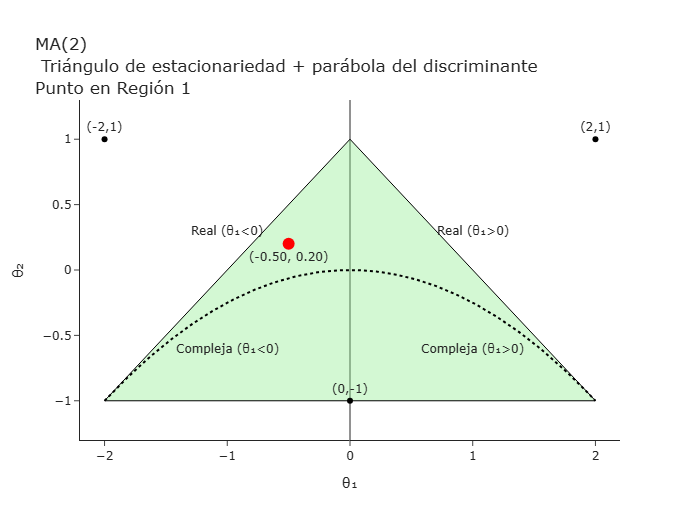

https://nuriaarroyo.github.io/ecoII/interactive/MA_2_br_Tri%C3%A1ngulo_de_estacionariedad_par%C3%A1bola_del_discriminante_br_Punto_en_Regi%C3%B3n_1.html


In [8]:

fig = ma2_region_quad(t1, t2)
fig.show()

out_path, public_url, pdf_url = publisher.save_html(     fig,     site_subfolder="interactive",     print_link=False, ) 
print(pdf_url)

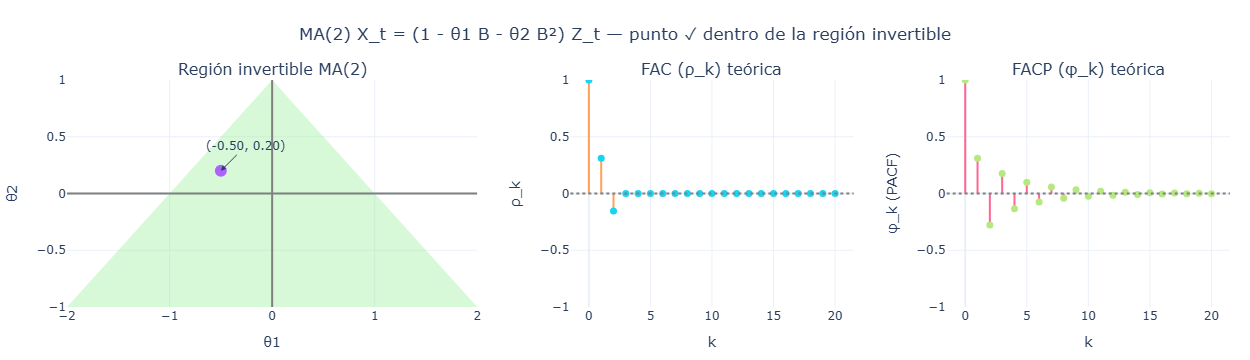

https://nuriaarroyo.github.io/ecoII/interactive/MA_2_X_t_1_-_%CE%B81_B_-_%CE%B82_B%C2%B2_Z_t_punto_dentro_de_la_regi%C3%B3n_invertible.html


In [9]:
fig = panel_ma2(theta1=t1, theta2=t2, m=20)
fig.show()
out_path, public_url, pdf_url = publisher.save_html(     fig,     site_subfolder="interactive",     print_link=False, ) 
print(pdf_url)

**Modelo MA(2):**

$$
W_t = (1 - \theta_1 B - \theta_2 B^2) a_t
$$

En el plano $(\theta_1, \theta_2)$, esta región está dentro del triángulo de invertibilidad donde se cumple:

- $\theta_1^2 + 4\theta_2 > 0$
- $\theta_1 < 0$


**FAC teórica**

Comportamiento de la función de autocorrelación:

$$
\rho_k =
\begin{cases}
\displaystyle\frac{-\theta_1 (1 - \theta_2)}{1 + \theta_1^2 + \theta_2^2} & \text{si } k = 1 \\
\displaystyle\frac{-\theta_2 + \theta_1^2 \theta_2}{1 + \theta_1^2 + \theta_2^2} & \text{si } k = 2 \\
0 & \text{si } k \geq 3
\end{cases}
$$

**FACP:**

- La función de autocorrelación parcial muestra valores distintos de cero en los primeros dos lags, truncándose a partir del tercero.

**Comportamiento:**

> Solo $\rho_1$ y $\rho_2$ son autocorrelaciones distintas de cero.
> A partir de $\rho_3$, todas las autocorrelaciones serán igual a cero.





**Ejemplo: Proceso MA(2)**

Dado el proceso:

$$
W_t = (1 + 0.5B - 0.2B^2)a_t
$$

**Parámetros:**

- $\theta_1 = -0.5$
- $\theta_2 = 0.2$



**Verificación del discriminante:**

$$
\theta_1^2 + 4\theta_2 = (-0.5)^2 + 4(0.2) = 0.25 + 0.8 = 1.05 > 0
$$


**Se cumplen las 3 condiciones de invertibilidad:**

1. $|\theta_2| = 0.2 < 1$

2. $\theta_1 + \theta_2 = -0.5 + 0.2 = -0.3 < 1$

3. $\theta_2 - \theta_1 = 0.2 - (-0.5) = 0.7 < 1$



**FAC teórica:**

La fórmula general para el proceso MA(2) es:

$$
\rho_k =
\begin{cases}
\displaystyle\frac{-\theta_1 (1 - \theta_2)}{1 + \theta_1^2 + \theta_2^2} & \text{si } k = 1 \\\\
\displaystyle\frac{-\theta_2 + \theta_1^2 \theta_2}{1 + \theta_1^2 + \theta_2^2} & \text{si } k = 2 \\\\
0 & \text{si } k \geq 3
\end{cases}
$$

**Cálculo numérico:**

1. Para $k = 1$:

$$
\rho_1 = \frac{-(-0.5)(1 - 0.2)}{1 + (-0.5)^2 + (0.2)^2}
= \frac{(0.5)(0.8)}{1 + 0.25 + 0.04}
= \frac{0.4}{1.29} \approx 0.31
$$

2. Para $k = 2$:

$$
\rho_2 = \frac{-0.2 + (-0.5)^2(0.2)}{1.29}
= \frac{-0.2 + 0.05}{1.29}
= \frac{-0.15}{1.29} \approx -0.116
$$

3. Para $k \geq 3$:

$$
\rho_k = 0
$$




**Gráfico de la FAC teórica:**

Visualmente se observan solo $\rho_1$ y $\rho_2$ distintos de cero. El resto son cero.


In [10]:
import numpy as np
import plotly.graph_objects as go

# ========= ACF teórica MA(2) =========
# sign="minus": X_t = (1 - θ1 B - θ2 B^2) Z_t
# sign="plus" : X_t = (1 + θ1 B + θ2 B^2) Z_t
def acf_ma2(theta1, theta2, m, sign="minus"):
    lags = np.arange(m + 1)
    rho  = np.zeros(m + 1, dtype=float)

    denom = 1.0 + theta1**2 + theta2**2
    rho[0] = 1.0

    if sign == "minus":
        if m >= 1:
            rho[1] = (theta1 * (theta2 - 1.0)) / denom
        if m >= 2:
            rho[2] = (-theta2) / denom
    elif sign == "plus":
        if m >= 1:
            rho[1] = (theta1 * (1.0 + theta2)) / denom
        if m >= 2:
            rho[2] = (theta2) / denom
    else:
        raise ValueError("sign debe ser 'minus' o 'plus'")

    return lags, rho


# ========= Stemplot (stems azules, puntos rojos) =========
def acf_stemplot_plotly(lags, rho, title="FAC (ρ_k)", width=700, height=380):
    # stems: segmentos verticales azules
    xs, ys = [], []
    for k, r in zip(lags, rho):
        xs += [k, k, None]
        ys += [0, r, None]

    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=xs, y=ys,
        mode="lines",
        line=dict(color="blue", width=2),
        showlegend=False
    ))

    # puntos: bolitas rojas
    fig.add_trace(go.Scatter(
        x=lags, y=rho,
        mode="markers",
        marker=dict(size=8, color="red"),
        showlegend=False,
        hovertemplate="k=%{x}<br>ρ_k=%{y:.4f}<extra></extra>"
    ))

    # línea horizontal en 0
    fig.add_hline(y=0, line_dash="dot", line_color="gray")

    fig.update_layout(
        template="plotly_white",
        width=width,
        height=height,
        title=title,
        xaxis_title="k",
        yaxis_title="ρ_k",
        yaxis=dict(range=[-1, 1])
    )
    return fig


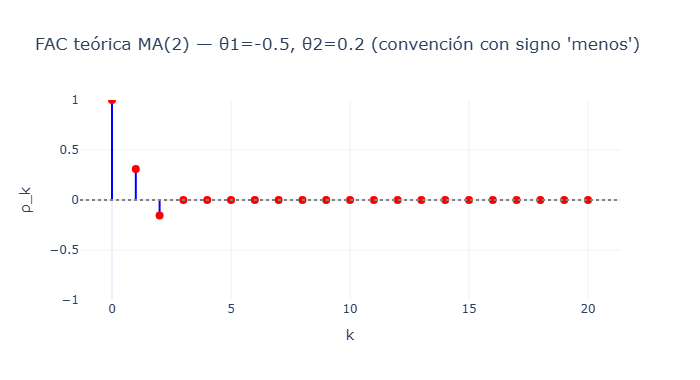

https://nuriaarroyo.github.io/ecoII/interactive/FAC_te%C3%B3rica_MA_2_%CE%B81_-0_5_%CE%B82_0_2_convenci%C3%B3n_con_signo_menos.html


In [11]:

m=20
lags, rho = acf_ma2(t1, t2, m, sign="minus")
fig = acf_stemplot_plotly(
    lags, rho,
    title=f"FAC teórica MA(2) — θ1={t1}, θ2={t2} (convención con signo 'menos')"
)
fig.show()
out_path, public_url, pdf_url = publisher.save_html(     fig,     site_subfolder="interactive",     print_link=False, ) 
print(pdf_url)


**Nota:**

Se puede probar que:

- $|\rho_1| \leq 0.5$
- $|\rho_2| \leq 0.5$

---


**Región Admisible #2: Discriminante > 0 y $\theta_{1} > 0$**

Consideramos el modelo:

$$
W_t = (1 - \theta_1 B - \theta_2 B^2)\alpha_t
$$



In [12]:
t1 = 0.3
t2 = 0.4


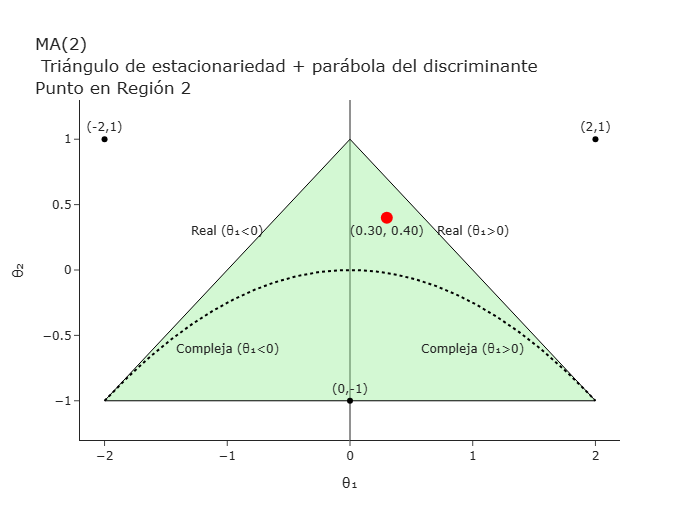

https://nuriaarroyo.github.io/ecoII/interactive/MA_2_br_Tri%C3%A1ngulo_de_estacionariedad_par%C3%A1bola_del_discriminante_br_Punto_en_Regi%C3%B3n_2.html


In [13]:


fig = ma2_region_quad(t1, t2)
fig.show()
out_path, public_url, pdf_url = publisher.save_html(     fig,     site_subfolder="interactive",     print_link=False, ) 
print(pdf_url)

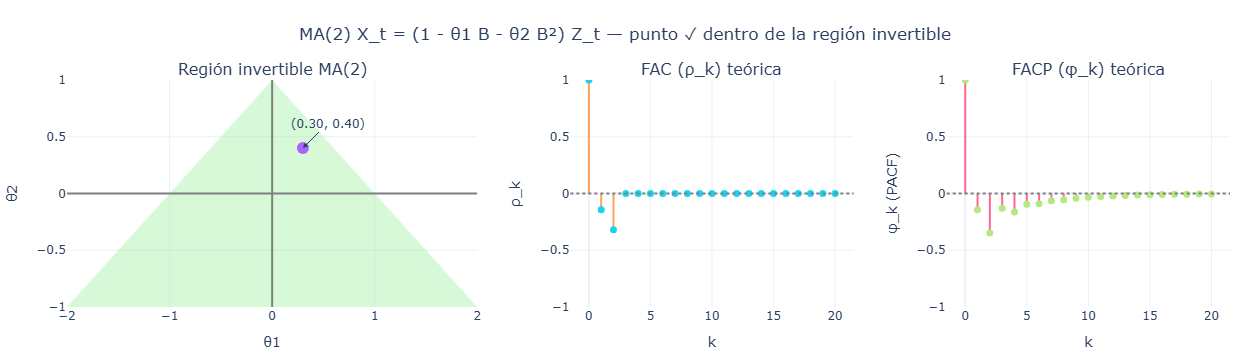

https://nuriaarroyo.github.io/ecoII/interactive/MA_2_X_t_1_-_%CE%B81_B_-_%CE%B82_B%C2%B2_Z_t_punto_dentro_de_la_regi%C3%B3n_invertible.html


In [14]:
fig = panel_ma2(theta1=t1, theta2=t2, m=20)
fig.show()
out_path, public_url, pdf_url = publisher.save_html(     fig,     site_subfolder="interactive",     print_link=False, ) 
print(pdf_url)



**Condiciones:**

- $\theta_1^2 + 4\theta_2 > 0$
- $\theta_2 > 0$


**FAC teórica:**

$$
\rho_k =
\begin{cases}
-\frac{\theta_1 (1 - \theta_2)}{1 + \theta_1^2 + \theta_2^2} & \text{si } k = 1 \\
-\frac{\theta_2}{1 + \theta_1^2 + \theta_2^2} & \text{si } k = 2 \\
0 & \text{si } k \geq 3
\end{cases}
$$

**Comportamiento:**
> Solo $\rho_1$ y $\rho_2$ son autocorrelaciones distintas de cero.

**Ejemplo**

Modelo:

$$
W_t = (1 - 0.3B - 0.4B^2)\alpha_t
$$

Parámetros:

- $\theta_1 = 0.3$
- $\theta_2 = 0.4$

Comprobación:

$$
\theta_1^2 + 4\theta_2 = (0.3)^2 + 4(0.4) = 0.09 + 1.6 = 1.69 > 0
$$



**Condiciones de invertibilidad:**

- $|\theta_2| = |0.4| < 1$
- $\theta_2 + \theta_1 = 0.7 < 1$
- $\theta_2 - \theta_1 = 0.1 < 1$

Cumple con las condiciones de invertibilidad



- $\theta_1 = 0.3$
- $\theta_2 = 0.4$

**Fórmulas:**

$$
\rho_k =
\begin{cases}
-\dfrac{\theta_1 (1 - \theta_2)}{1 + \theta_1^2 + \theta_2^2} & \text{si } k = 1 \\
-\dfrac{\theta_2}{1 + \theta_1^2 + \theta_2^2} & \text{si } k = 2 \\
0 & \text{si } k \geq 3
\end{cases}
$$


 Sustituyendo los valores

- $\rho_1 = -\dfrac{0.3 (1 - 0.4)}{1 + 0.3^2 + 0.4^2} = -\dfrac{0.3 (0.6)}{1 + 0.09 + 0.16} = -\dfrac{0.18}{1.25} = -0.144$

- $\rho_2 = -\dfrac{0.4}{1.25} = -0.32$

- $\rho_k = 0$ para $k \geq 3$



$$
\rho_k =
\begin{cases}
-0.14 & \text{si } k = 1 \\
-0.32 & \text{si } k = 2 \\
0 & \text{si } k \geq 3
\end{cases}
$$

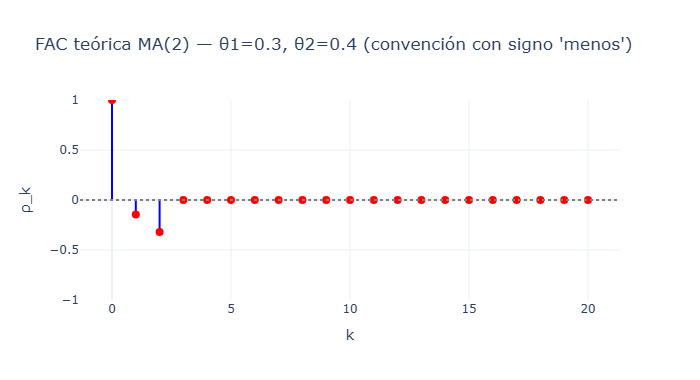

https://nuriaarroyo.github.io/ecoII/interactive/FAC_te%C3%B3rica_MA_2_%CE%B81_0_3_%CE%B82_0_4_convenci%C3%B3n_con_signo_menos.html


In [15]:

lags, rho = acf_ma2(t1, t2, m, sign="minus")
fig = acf_stemplot_plotly(
    lags, rho,
    title=f"FAC teórica MA(2) — θ1={t1}, θ2={t2} (convención con signo 'menos')"
)
fig.show()
out_path, public_url, pdf_url = publisher.save_html(     fig,     site_subfolder="interactive",     print_link=False, ) 
print(pdf_url)

---


**Región Admisible #3: Discriminante < 0 ; $\theta_{1} < 0$**

**Modelo:**

$$
W_t = (1 - \theta_1 B - \theta_2 B^2) \alpha_t
$$



In [16]:
t1 = -0.5
t2 = -0.7



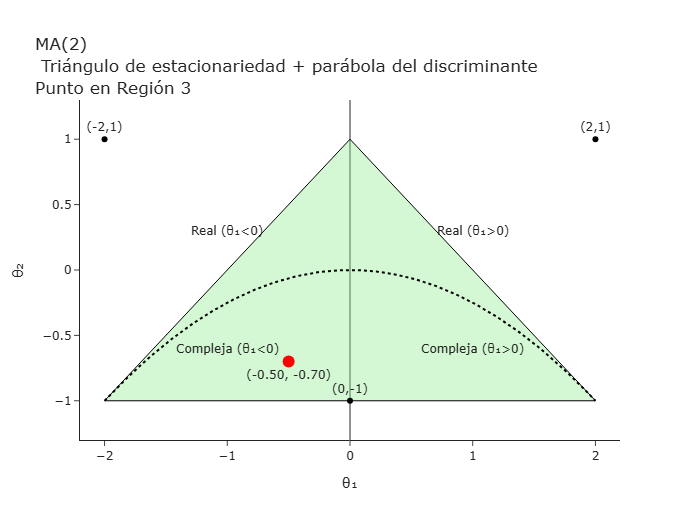

https://nuriaarroyo.github.io/ecoII/interactive/MA_2_br_Tri%C3%A1ngulo_de_estacionariedad_par%C3%A1bola_del_discriminante_br_Punto_en_Regi%C3%B3n_3.html


In [17]:

fig = ma2_region_quad(t1, t2)
fig.show()
out_path, public_url, pdf_url = publisher.save_html(     fig,     site_subfolder="interactive",     print_link=False, ) 

print(pdf_url)

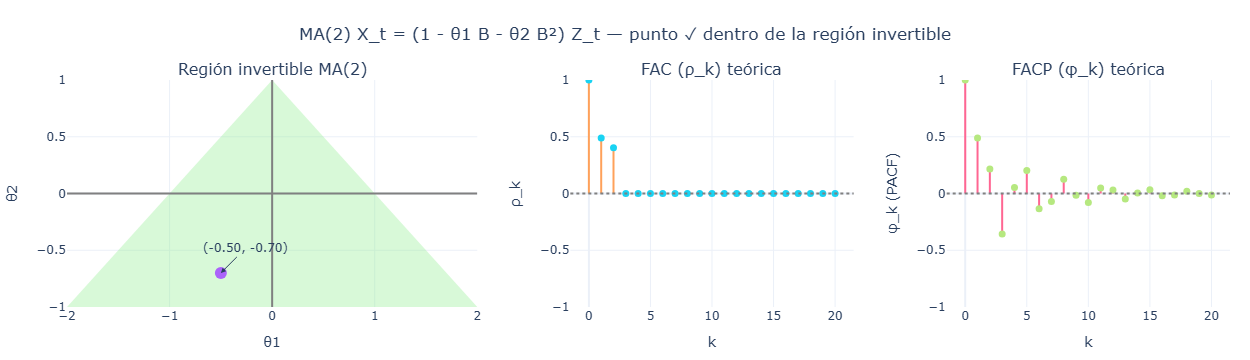

https://nuriaarroyo.github.io/ecoII/interactive/MA_2_X_t_1_-_%CE%B81_B_-_%CE%B82_B%C2%B2_Z_t_punto_dentro_de_la_regi%C3%B3n_invertible.html


In [18]:
fig = panel_ma2(theta1=t1, theta2=t2, m=20)
fig.show()
out_path, public_url, pdf_url = publisher.save_html(     fig,     site_subfolder="interactive",     print_link=False, ) 
print(pdf_url)


**Ejemplo:**

$$
W_t = (1 + 0.5B + 0.7B^2) \alpha_t
$$

**Parámetros:**

- $\theta_1 = -0.5$
- $\theta_2 = -0.7$

**Discriminante:**

$$
\theta_1^2 + 4\theta_2 = (-0.5)^2 + 4(-0.7) = 0.25 - 2.8 = -2.55 < 0
$$

**Se cumplen las condiciones de invertibilidad:**

- $|\theta_2| = 0.7 < 1$
- $\theta_1 + \theta_2 = -1.2 < 1$
- $\theta_2 - \theta_1 = -0.2 < 1$

**FAC teórica:**

$$
\rho_k =
\begin{cases}
-\dfrac{\theta_1 (1 - \theta_2)}{1 + \theta_1^2 + \theta_2^2} & \text{si } k = 1 \\
-\dfrac{\theta_2}{1 + \theta_1^2 + \theta_2^2} & \text{si } k = 2 \\
0 & \text{si } k \geq 3
\end{cases}
$$

**Sustituyendo:**

- $\rho_1 = -\dfrac{-0.5 (1 - (-0.7))}{1 + (-0.5)^2 + (-0.7)^2} = \dfrac{0.5 \cdot 1.7}{1 + 0.25 + 0.49} = \dfrac{0.85}{1.74} \approx 0.488$
- $\rho_2 = -\dfrac{-0.7}{1.74} = 0.402$
- $\rho_k = 0$ para $k \geq 3$

**Resultado final:**

$$
\rho_k =
\begin{cases}
0.48 & \text{si } k = 1 \\
0.40 & \text{si } k = 2 \\
0 & \text{si } k \geq 3
\end{cases}
$$


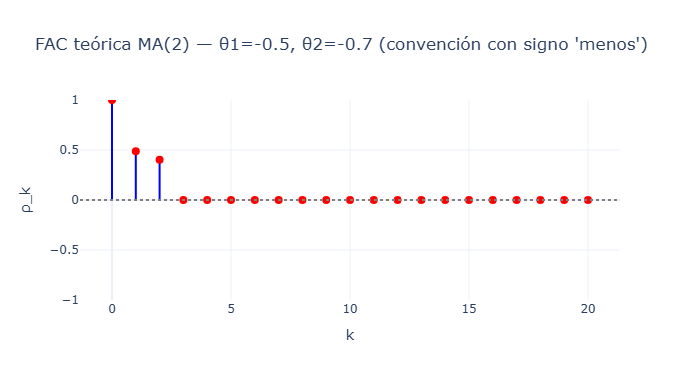

https://nuriaarroyo.github.io/ecoII/interactive/FAC_te%C3%B3rica_MA_2_%CE%B81_-0_5_%CE%B82_-0_7_convenci%C3%B3n_con_signo_menos.html


In [19]:

lags, rho = acf_ma2(t1, t2, m, sign="minus")
fig = acf_stemplot_plotly(
    lags, rho,
    title=f"FAC teórica MA(2) — θ1={t1}, θ2={t2} (convención con signo 'menos')"
)
fig.show()
out_path, public_url, pdf_url = publisher.save_html(     fig,     site_subfolder="interactive",     print_link=False, ) 
print(pdf_url)


---

**Región Admisible #3: Discriminante < 0 ; $\theta_{1} < 0$**

**Modelo:**

$$
W_t = (1 - \theta_1 B - \theta_2 B^2) \alpha_t
$$


In [20]:
t1 = 0.7
t2 = -0.5



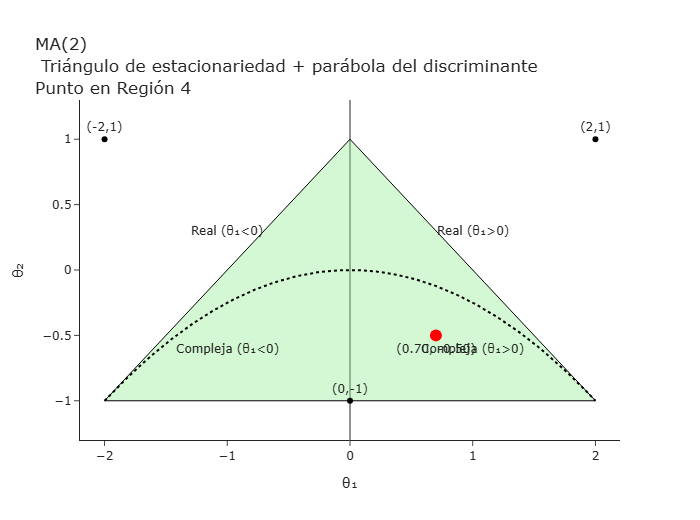

https://nuriaarroyo.github.io/ecoII/interactive/MA_2_br_Tri%C3%A1ngulo_de_estacionariedad_par%C3%A1bola_del_discriminante_br_Punto_en_Regi%C3%B3n_4.html


In [21]:

fig = ma2_region_quad(t1, t2)
fig.show()
out_path, public_url, pdf_url = publisher.save_html(     fig,     site_subfolder="interactive",     print_link=False, ) 
print(pdf_url)

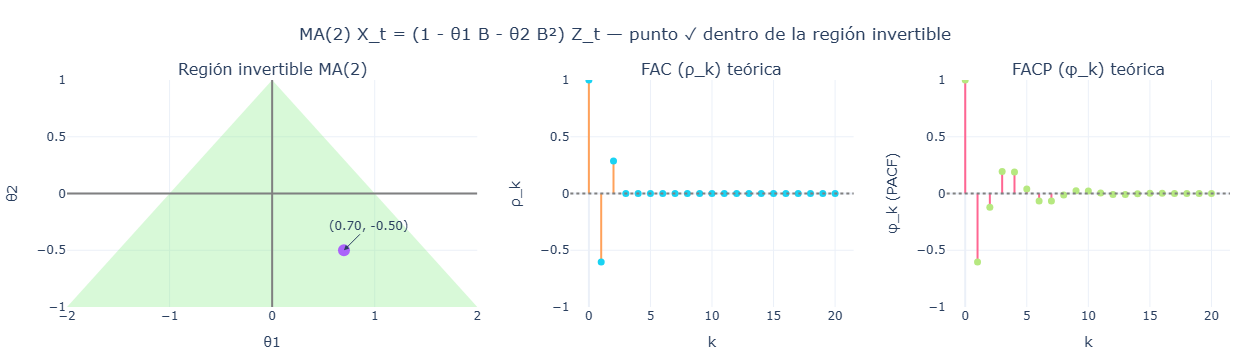

https://nuriaarroyo.github.io/ecoII/interactive/MA_2_X_t_1_-_%CE%B81_B_-_%CE%B82_B%C2%B2_Z_t_punto_dentro_de_la_regi%C3%B3n_invertible.html


In [22]:

fig = panel_ma2(theta1=t1, theta2=t2, m=20)
fig.show()
out_path, public_url, pdf_url = publisher.save_html(     fig,     site_subfolder="interactive",     print_link=False, ) 
print(pdf_url)


**Ejemplo:**

$$
W_t = (1 + 0.5B + 0.7B^2) \alpha_t
$$

**Parámetros:**

- $\theta_1 = 0.7$
- $\theta_2 = -0.5$

**Discriminante:**

$$
\theta_1^2 + 4\theta_2 = (0.7)^2 + 4(-0.5) = 0.49 - 2 = -1.51 < 0
$$

**Se cumplen las condiciones de invertibilidad:**

- $|\theta_1| = 0.7 < 1$
- $\theta_1 + \theta_2 = 0.2 < 1$
- $\theta_2 - \theta_1 = -0.12< 1$

**FAC teórica:**

$$
\rho_k =
\begin{cases}
-\dfrac{\theta_1 (1 - \theta_2)}{1 + \theta_1^2 + \theta_2^2} & \text{si } k = 1 \\
-\dfrac{\theta_2}{1 + \theta_1^2 + \theta_2^2} & \text{si } k = 2 \\
0 & \text{si } k \geq 3
\end{cases}
$$

**Sustituyendo:**

- $\rho_1 = -\dfrac{-0.7 (1 - (-0.5))}{1 + (0.7)^2 + (-0.5)^2} =\dfrac{-0.7 (1.5)}{1 + (0.7)^2 + (-0.5)^2}  = -0.603 $
- $\rho_2 = -\dfrac{-0.5}{1.74} = 0.28$
- $\rho_k = 0$ para $k \geq 3$

**Resultado final:**

$$
\rho_k =
\begin{cases}
-0.603 & \text{si } k = 1 \\
0.28 & \text{si } k = 2 \\
0 & \text{si } k \geq 3
\end{cases}
$$
